# Statistical Hypothesis Testing

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Defining seed for reproducibility
np.random.seed(42)

colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
})


## Exercise 1

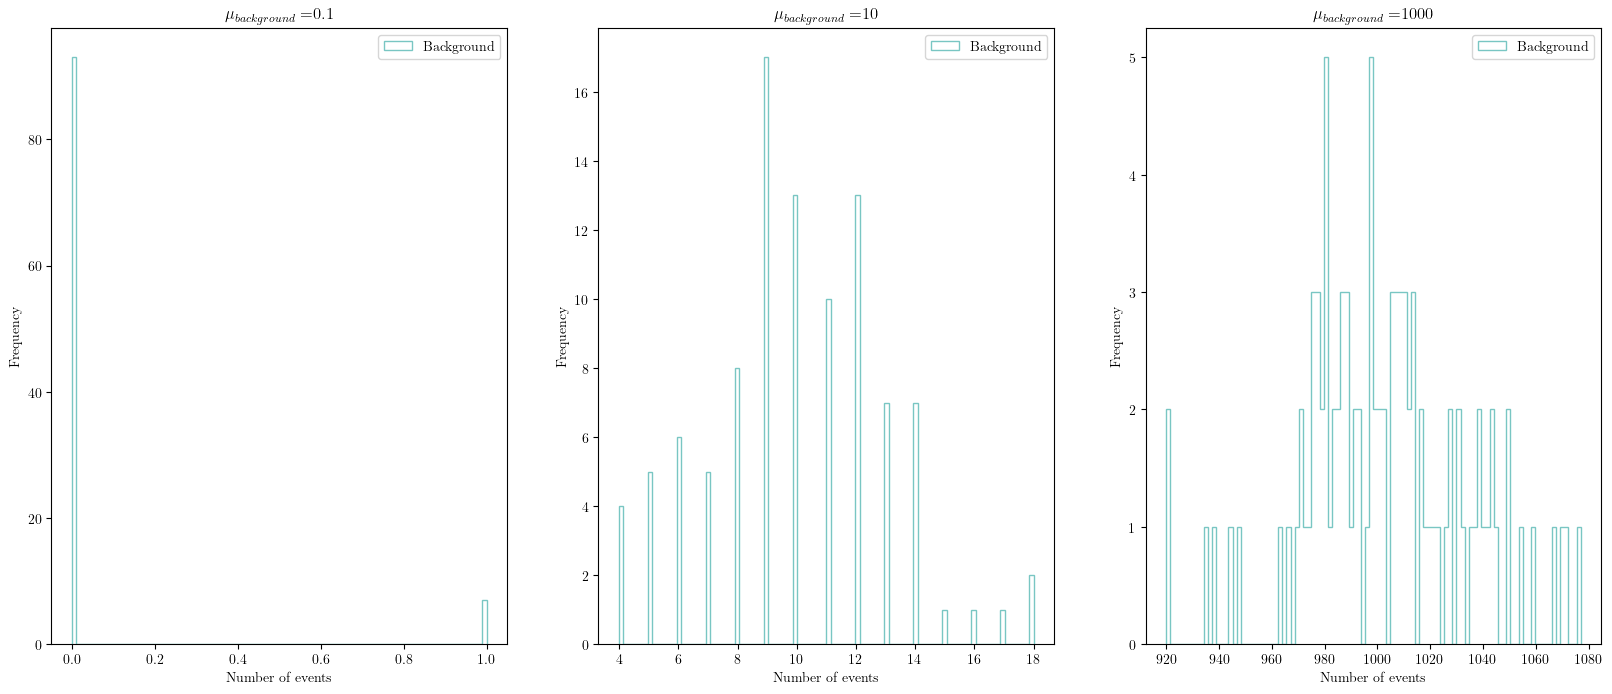

In [68]:
# Three background cases with mu_signal = 0 and mu_background = 0.1, 10, 1000
mu_background = [0.1, 10, 1000]
mu_signal = 0

N_bins = 100
runs = 1

"""mu_background and mu_signal are the mean values of the Poisson distribution for the background and signal respectively - 
i.e. the expected number of events in the bin."""

fig, ax = plt.subplots(1, 3, figsize = (20, 8))
for i, mu_b in enumerate(mu_background):
    # Generate the data
    data = np.random.poisson(mu_b, (runs, N_bins))
    data = np.append(data, np.zeros(mu_signal))

    # Plotting the data 
    ax[i].hist(data.flatten(), bins = N_bins, histtype = 'step', color = colors[0], alpha = 0.7, label = 'Background')
    ax[i].set_xlabel('Number of events')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(r'$\mu_{background} = $' + str(mu_b))
    ax[i].legend()

In [93]:
new_runs = 1000

def generate_data(mu_b, mu_s, N_bins, new_runs):
    data = np.random.poisson(mu_b, (new_runs, N_bins))
    data = np.append(data, np.zeros(mu_s))

    return data

In [94]:
# Making function for calculating lambda
def test_statistic(background, N_bins):
    N_tot = len(background)
    background_0 = background[0]

    scale = N_bins / N_tot

    first_term_value = scale * background_0
    second_term_value = scale * ((N_tot - background_0) / (N_bins - 1))

    first_term = 2 * background_0 * np.log(first_term_value) if first_term_value > 0 else 0
    second_term = 2 * (N_tot - background_0) * np.log(second_term_value) if second_term_value > 0 else 0

    return first_term + second_term

def full_experiment(N_bins, new_runs, mu_b, mu_s):
    lambda_values = np.zeros(new_runs)
    for i in range(new_runs):
        background = generate_data(mu_b, mu_s, N_bins, new_runs)
        lambda_values[i] = test_statistic(background, N_bins)

    return lambda_values

In [95]:
# Calculating lambda for each case
lambda_values = []
for mu_b in mu_background:
    lambda_values.append(full_experiment(N_bins, new_runs, mu_b, mu_signal))

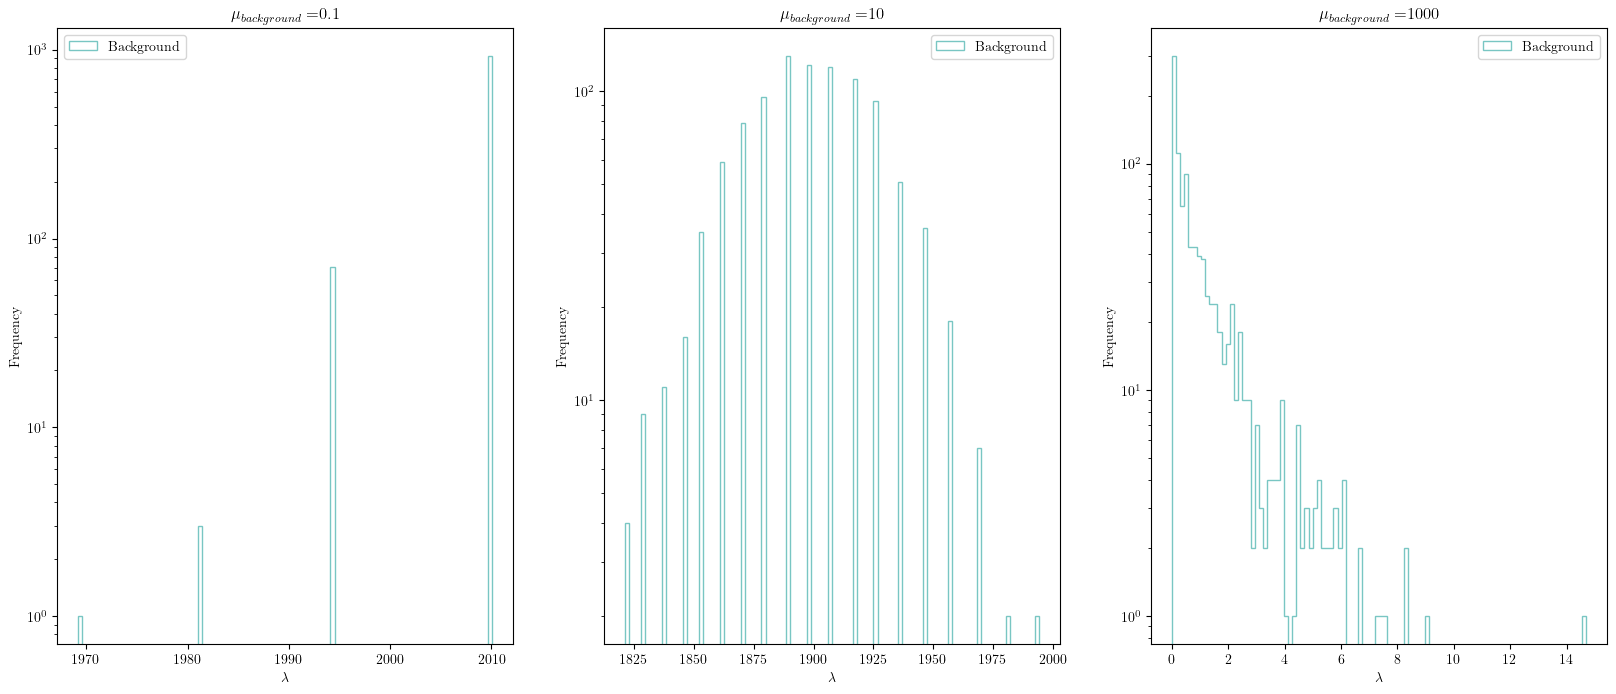

In [85]:
# Plotting the results
fig, ax = plt.subplots(1, 3, figsize = (20, 8))

for i, mu_b in enumerate(mu_background):
    ax[i].hist(lambda_values[i], bins = 100, histtype = 'step', color = colors[0], alpha = 0.7, label = 'Background')
    ax[i].set_xlabel(r'$\lambda$')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(r'$\mu_{background} = $' + str(mu_b))
    ax[i].legend()
    ax[i].set_yscale('log')

## Generating Monte Carlo uniformly on a sphere

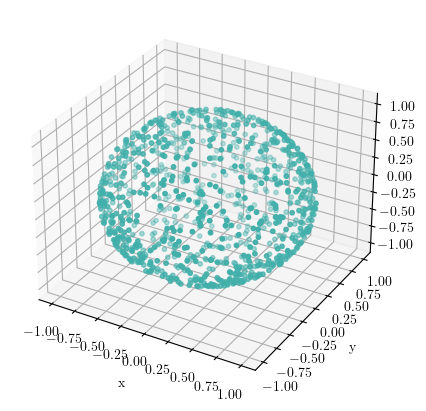

In [152]:
# Generating Monte Carlo points uniformly on a sphere
def generate_sphere_points(N_points):
    """We have to use the inverse transform method to generate points uniformly on a sphere. If we just generate points uniformly in 3D space, we will
     overestimate the density of points near the poles and underestimate the density near the equator. This is because the area of a sphere is not the same."""

    phi = np.random.uniform(0, 2 * np.pi, N_points)                     # Azimuthal angle
    theta = np.arccos(2 * np.random.uniform(0, 1, N_points) - 1)        # Zenith angle

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    return x, y, z

N_points = 1000

x, y, z = generate_sphere_points(N_points)

fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(x, y, z, s = 10, color = colors[0])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

### Exercise 2 - Event distribution

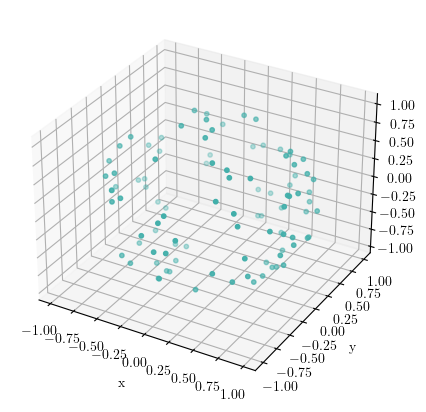

In [153]:
# Isotropic distribution of points
N_tot = 100

x, y, z = generate_sphere_points(N_tot)

fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(x, y, z, s = 10, color = colors[0])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

Text(0, 0.5, '$C(\\phi)$')

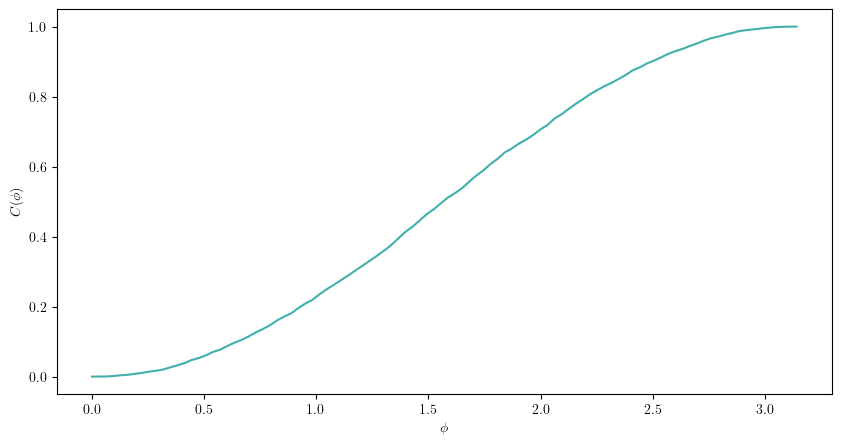

In [163]:
# Two-point autocorrelation function
def two_point_auto_corr(N_tot, phi_values):
    scale = 2 / (N_tot * (N_tot - 1))

    x, y, z = generate_sphere_points(N_tot)

    C_phi = 0

    for i in range(N_tot):
        for j in range(i):  
            if i == j:
                continue
            cos_ij = x[i] * x[j] + y[i] * y[j] + z[i] * z[j]
            # Applying the heaviside function (sum(heaviside(cos_ij - cos(phi))) for all i, j)
            heaviside_values = np.where(cos_ij - np.cos(phi_values) > 0, 1, 0)
            C_phi += heaviside_values

    return scale * C_phi

N_tot = 100
phi_values = np.linspace(0, np.pi, 100)
C_phi = two_point_auto_corr(N_tot, phi_values)

fig, ax = plt.subplots(1, 1, figsize = (10, 5))
ax.plot(phi_values, C_phi, color = colors[0])
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$C(\phi)$')
